# Global preparations

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import logging
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision.transforms.functional import to_pil_image
from PIL import Image
from tqdm.notebook import tqdm

torch.set_float32_matmul_precision('high')
import warnings
import torch._dynamo
torch._dynamo.config.cache_size_limit = 128
warnings.filterwarnings(
    "ignore",
    message=".*has_cuda.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_cudnn.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_mps.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_mkldnn.*deprecated.*"
)

device = 'cuda:4'
summation_dtype = torch.float32
random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)
torch.backends.cudnn.enabled = True

# MNIST preparation

Let's read the MNIST dataset and represent it in sparse form

In [3]:
mnist_dataset_dir = 'mnist'

import torchvision.transforms as T

mnist_train_dataset = torchvision.datasets.MNIST(
    mnist_dataset_dir, train=True, download=True
)
mnist_test_dataset = torchvision.datasets.MNIST(
    mnist_dataset_dir, train=False, download=True
)
mnist_train_data_device = mnist_train_dataset.data.to(device=device).to(dtype=torch.float32) / 255
mnist_test_data_device = mnist_test_dataset.data.to(device=device).to(dtype=torch.float32) / 255
mnist_train_targets_device = mnist_train_dataset.targets.to(device=device)
mnist_test_targets_device = mnist_test_dataset.targets.to(device=device)

mnist_train_dataset = TensorDataset(
    mnist_train_data_device, mnist_train_targets_device
)
mnist_test_dataset = TensorDataset(
    mnist_test_data_device, mnist_test_targets_device
)

In [4]:
mnist_test_loader = torch.utils.data.DataLoader(
    mnist_train_dataset,
    batch_size=10, shuffle=True
)

example_data, example_targets = next(iter(mnist_test_loader))
to_pil_image(example_data[0])

# Layered ProjectionLUT

In [5]:
from spiky.lutorch.multi_head_lut import ProjectionLUT, UnfoldConfiguration

H, W = 28, 28
O1, O2 = 6, 6

class TwoLayerProjectionLUT(nn.Module):
    """
    Two-layer ProjectionLUT-based conv-like network for MNIST, implemented
    using the new LUTorch `ProjectionLUT`.
    """

    def __init__(
        self, device: torch.device, input_shape = (H, W), 
        hidden_outputs = (O1, O2), num_classes: int = 10
    ):
        super().__init__()

        H, W = input_shape
        O1, O2 = hidden_outputs

        unfold1 = UnfoldConfiguration(
            H=H,
            W=W,
            kernel_size=5,
            stride=2,
        )
        fold1 = UnfoldConfiguration(
            H=H,
            W=W,
            kernel_size=5,
            stride=2,
        )
        
        self.proj1 = ProjectionLUT(
            unfold_config=unfold1,
            fold_config=fold1,
            n_outputs=O1,
            smooth_mode=True,
            n_alternatives=3,
            initial_weights_noise=0.001,
            n_anchor_pairs=4,
            tables_per_head=32,
            device=device,
        )

        unfold2 = UnfoldConfiguration(
            H=H,
            W=W,
            kernel_size=10,
            stride=2,
        )
        fold2 = UnfoldConfiguration(
            H=H,
            W=W,
            kernel_size=10,
            stride=2,
        )
        self.proj2 = ProjectionLUT(
            unfold_config=unfold2,
            fold_config=fold2,
            n_outputs=O2,
            smooth_mode=True,
            n_alternatives=3,
            initial_weights_noise=0.001,
            n_anchor_pairs=4,
            tables_per_head=32,
            device=device,
        )
        
        self.drop = nn.Dropout(0.2)

        self.final_layer = nn.Linear(H * W, num_classes, device=device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, H, W]
        x1 = self.proj1(x)  # [B, H, W]
        x2 = self.proj2(self.drop(x1))  # [B, H, W]
        return self.final_layer(self.drop(x2.view(x.shape[0], -1)))


Process ForkProcess-7:
Process ForkProcess-32:
Process ForkProcess-18:
Process ForkProcess-26:
Process ForkProcess-13:
Process ForkProcess-8:
Process ForkProcess-16:
Process ForkProcess-10:
Process ForkProcess-4:
Process ForkProcess-3:
Process ForkProcess-27:
Process ForkProcess-23:
Process ForkProcess-29:
Process ForkProcess-2:
Process ForkProcess-20:
Process ForkProcess-24:
Process ForkProcess-19:
Process ForkProcess-15:
Process ForkProcess-1:
Traceback (most recent call last):
Process ForkProcess-21:
Process ForkProcess-6:
Process ForkProcess-17:
Process ForkProcess-25:
Process ForkProcess-9:
Traceback (most recent call last):
Process ForkProcess-28:
Process ForkProcess-30:
Process ForkProcess-14:
Traceback (most recent call last):
Process ForkProcess-22:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process ForkProcess-31:
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, i

  File "/usr/lib/python3.8/concurrent/futures/process.py", line 233, in _process_worker
    call_item = call_queue.get(block=True)
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/concurrent/futures/process.py", line 233, in _process_worker
    call_item = call_queue.get(block=True)
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/concurrent/futures/process.py", line 233, in _process_worker
    call_item = call_queue.get(block=True)
  File "/usr/lib/python3.8/multiprocessing/queues.py", line 96, in get
    with self._rlock:
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/multiproces

In [21]:
proj_lut_net = TwoLayerProjectionLUT(device)
# Count parameters
lut_total_params = sum(p.numel() for p in proj_lut_net.parameters())
lut_trainable_params = sum(p.numel() for p in proj_lut_net.parameters() if p.requires_grad)

print(f"Projection LUT Model: {proj_lut_net}")
print(f"Total parameters: {lut_total_params:,}")
print(f"Trainable parameters: {lut_trainable_params:,}")

Projection LUT Model: TwoLayerProjectionLUT(
  (proj1): ProjectionLUT(
    (lut): MultiHeadLut(
      (lookup): AnchorPairsLookup()
      (projection): LProjection()
    )
  )
  (proj2): ProjectionLUT(
    (lut): MultiHeadLut(
      (lookup): AnchorPairsLookup()
      (projection): LProjection()
    )
  )
  (drop): Dropout(p=0.2, inplace=False)
  (final_layer): Linear(in_features=784, out_features=10, bias=True)
)
Total parameters: 757,418
Trainable parameters: 757,418


In [22]:
proj_lut_net(example_data)

tensor([[-1.8014e-02, -3.2839e-02, -1.2830e-02, -1.3841e-03,  1.1086e-02,
          8.9603e-03, -2.1191e-02,  1.4680e-02,  1.3378e-02,  2.3518e-03],
        [-1.7327e-02, -3.6979e-02, -1.2838e-02, -4.5488e-04,  1.6207e-02,
          4.7507e-03, -2.3422e-02,  1.3883e-02,  1.4904e-02,  6.3762e-03],
        [-1.9706e-02, -3.4170e-02, -1.4944e-02, -2.1390e-04,  1.4562e-02,
          7.3902e-03, -2.5130e-02,  1.4064e-02,  1.5345e-02,  6.2588e-03],
        [-1.8764e-02, -3.3988e-02, -1.5604e-02, -9.0331e-04,  1.9030e-02,
          5.1409e-03, -2.0724e-02,  1.1050e-02,  1.7479e-02,  1.7670e-03],
        [-1.7930e-02, -3.1096e-02, -1.1415e-02, -3.1361e-03,  1.5141e-02,
          7.4173e-03, -2.1781e-02,  1.0341e-02,  1.7031e-02,  5.7648e-04],
        [-1.8054e-02, -3.1654e-02, -1.3763e-02, -1.2612e-05,  1.6044e-02,
          4.7339e-03, -2.2550e-02,  1.3856e-02,  1.3441e-02,  5.2169e-03],
        [-1.7898e-02, -3.4850e-02, -1.0990e-02, -2.2324e-03,  1.5866e-02,
          8.8141e-03, -2.3142e-0

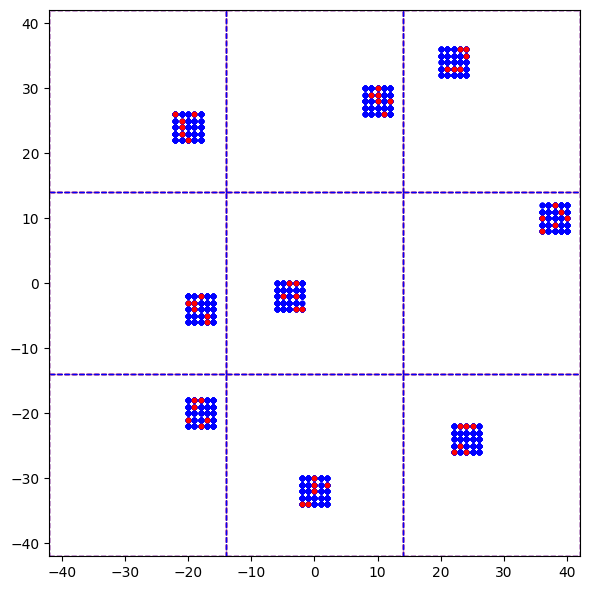

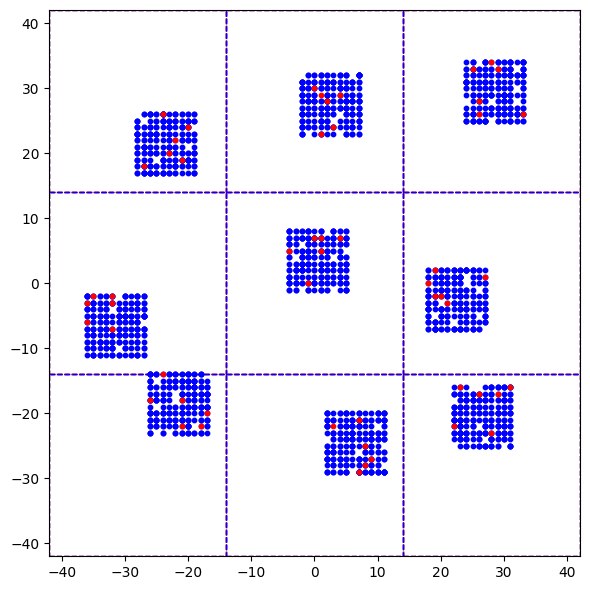

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

grid_side = 3

plt.close()

for proj_l in [proj_lut_net.proj1, proj_lut_net.proj2]:
    input_shape = (proj_l.unfold_config.H, proj_l.unfold_config.W)
    output_shape = (proj_l.fold_config.H, proj_l.fold_config.W)
    n_patches = proj_l.lut.n_heads
    n_detectors_per_patch = proj_l.lut.tables_per_head
    sample_ids = torch.arange(n_patches)[torch.randperm(n_patches)][:grid_side**2].numpy()

    plot_rectangle = (max(input_shape[0], output_shape[0]), max(input_shape[1], output_shape[1]))

    iy = (torch.arange(input_shape[0], device=device) - input_shape[0] / 2) # * (plot_rectangle[0] / input_shape[0])
    ix = (torch.arange(input_shape[1], device=device) - input_shape[1] / 2) # * (plot_rectangle[1] / input_shape[1])
    grid_iy, grid_ix = torch.meshgrid(iy, ix, indexing='ij')
    grid_iy = grid_iy.flatten()
    grid_ix = grid_ix.flatten()

    oy = (torch.arange(output_shape[0], device=device) - output_shape[0] / 2) # * (plot_rectangle[0] / output_shape[0])
    ox = (torch.arange(output_shape[1], device=device) - output_shape[1] / 2) # * (plot_rectangle[1] / output_shape[1])
    grid_oy, grid_ox = torch.meshgrid(oy, ox, indexing='ij')
    grid_oy = grid_oy.flatten()
    grid_ox = grid_ox.flatten()

    plt.close()
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_xlim((-plot_rectangle[1] / 2) * grid_side, (plot_rectangle[1] / 2) * grid_side)
    ax.set_ylim((-plot_rectangle[0] / 2) * grid_side, (plot_rectangle[0] / 2) * grid_side)

    anchors = torch.cat(
        [
            proj_l.lut.lookup.anchor_pairs_a.view(n_patches, -1), 
            proj_l.lut.lookup.anchor_pairs_b.view(n_patches, -1)
        ],
        dim=-1
    )
    outputs = proj_l.fold_output_indices
    for i in range(grid_side):
        for j in range(grid_side):
            center_x_shift = plot_rectangle[1] * (j - (grid_side / 2) + 0.5)
            center_y_shift = plot_rectangle[0] * ((grid_side / 2) - i - 0.5)
            rect = patches.Rectangle(
                (
                    center_x_shift - output_shape[1] / 2,
                    center_y_shift - output_shape[0] / 2
                ), output_shape[1], output_shape[0],
                fill=False, linestyle="--", linewidth=1, edgecolor="red"
            )
            ax.add_patch(rect)
            rect = patches.Rectangle(
                (
                    center_x_shift - input_shape[1] / 2,
                    center_y_shift - input_shape[0] / 2
                ), input_shape[1], input_shape[0],
                fill=False, linestyle="--", linewidth=1, edgecolor="blue"
            )
            ax.add_patch(rect)
            sample_id = sample_ids[i * grid_side + j]
            ys = -grid_iy[anchors[sample_id]] + center_y_shift
            xs = grid_ix[anchors[sample_id]] + center_x_shift
            ax.scatter(xs.cpu().numpy(), ys.cpu().numpy(), c="blue", s=10, label="set 1")
            ys = -grid_oy[outputs[sample_id]] + center_y_shift
            xs = grid_ox[outputs[sample_id]] + center_x_shift
            ax.scatter(xs.cpu().numpy(), ys.cpu().numpy(), c="red",  s=10, label="set 2")
    plt.tight_layout()
    plt.show()


In [24]:
train_accuracies = []
test_accuracies = []

In [25]:
optimizer = torch.optim.Adam(proj_lut_net.parameters(), lr=0.001)
n_epochs = 24
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=n_epochs
)
loss_func = nn.CrossEntropyLoss()
for epoch in range(n_epochs):
    proj_lut_net.train()
    train_loader = torch.utils.data.DataLoader(mnist_train_dataset, batch_size=256, shuffle=True)
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = proj_lut_net(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    train_acc = 100. * correct / len(train_loader.dataset)
    proj_lut_net.eval()
    correct = 0
    with torch.no_grad():
        test_loader = torch.utils.data.DataLoader(mnist_test_dataset, batch_size=256, shuffle=True)
        for data, target in test_loader:
            output = proj_lut_net(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_acc = 100. * correct / len(test_loader.dataset)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(
        f'Epoch {epoch+1} Train/test accuracy: {train_acc:.2f}/{test_acc:.2f}, '
        f'lr: {scheduler.get_last_lr()[0]:.5f}'
    )
    scheduler.step()

Epoch 1 Train/test accuracy: 91.51/97.94, lr: 0.00100
Epoch 2 Train/test accuracy: 97.98/98.47, lr: 0.00100
Epoch 3 Train/test accuracy: 98.69/98.78, lr: 0.00098
Epoch 4 Train/test accuracy: 99.09/98.80, lr: 0.00096
Epoch 5 Train/test accuracy: 99.28/98.70, lr: 0.00093
Epoch 6 Train/test accuracy: 99.54/98.81, lr: 0.00090
Epoch 7 Train/test accuracy: 99.61/98.87, lr: 0.00085
Epoch 8 Train/test accuracy: 99.71/98.81, lr: 0.00080
Epoch 9 Train/test accuracy: 99.77/98.96, lr: 0.00075
Epoch 10 Train/test accuracy: 99.82/98.82, lr: 0.00069
Epoch 11 Train/test accuracy: 99.86/98.96, lr: 0.00063
Epoch 12 Train/test accuracy: 99.88/98.95, lr: 0.00057
Epoch 13 Train/test accuracy: 99.90/98.92, lr: 0.00050
Epoch 14 Train/test accuracy: 99.92/98.96, lr: 0.00043
Epoch 15 Train/test accuracy: 99.94/98.85, lr: 0.00037
Epoch 16 Train/test accuracy: 99.95/98.86, lr: 0.00031
Epoch 17 Train/test accuracy: 99.96/98.87, lr: 0.00025
Epoch 18 Train/test accuracy: 99.94/98.94, lr: 0.00020
Epoch 19 Train/test

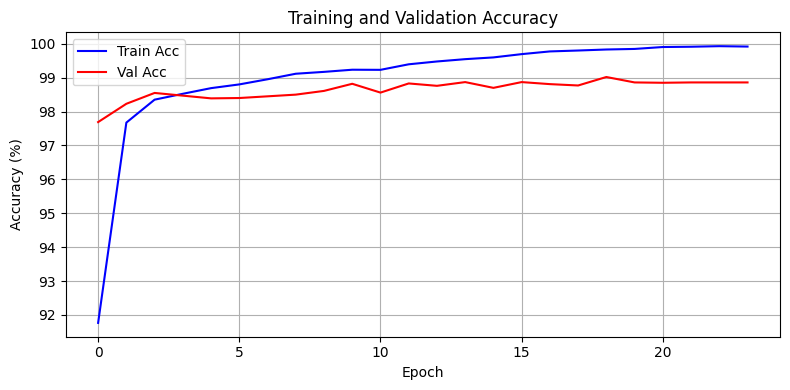

Best validation accuracy: 99.02% at epoch 19


In [16]:
# Plot training curves
fig, (ax2) = plt.subplots(1, 1, figsize=(8, 4))

# Accuracy plot
ax2.plot(train_accuracies, label='Train Acc', color='blue')
ax2.plot(test_accuracies, label='Val Acc', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(test_accuracies):.2f}% at epoch {test_accuracies.index(max(test_accuracies))+1}")


# LUT CNN

In [17]:
from spiky.lutorch.multi_head_lut import Conv2DLut, UnfoldConfiguration


class MNIST_LUT_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Base MNIST spatial size (input images are [B, 28, 28])
        H0, W0 = 28, 28  # input spatial H, W

        # --- Layer 1 configuration ---
        # patches: 5x5, stride 1 on 28x28
        # H1 = (28 - 5) // 1 + 1 = 24, W1 = 24 → n_patches = 24 * 24
        unfold1 = UnfoldConfiguration(H=H0, W=W0, kernel_size=5, stride=1)
        H1, W1 = unfold1.output_spatial_shape()

        # First Conv2DLut:
        #   input  x: [B, 1, 28, 28]
        #   per-patch vector dim = C * kH * kW = 1 * 5 * 5 = 25
        #   MultiHeadLut: input_dim=25, n_heads=1, tables_per_head=4
        #   output: [B, 8, H1, W1] = [B, 8, 24, 24]
        self.c1 = Conv2DLut(
            unfold_config=unfold1,
            in_channels=1,
            out_channels=8,
            n_anchor_pairs=4,
            smooth_mode=True,
            n_alternatives=3,
            tables_per_head=16,
            initial_weights_noise=0.001,
            device=device,
        )

        # --- Layer 2 configuration ---
        # patches: 5x5, stride 2 on 24x24
        # H2 = (24 - 5) // 2 + 1 = 10, W2 = 10 → n_patches = 10 * 10
        unfold2 = UnfoldConfiguration(H=H1, W=W1, kernel_size=5, stride=2)
        H2, W2 = unfold2.output_spatial_shape()

        # Second Conv2DLut:
        #   input  x: [B, 8, 24, 24]
        #   per-patch vector dim = 8 * 5 * 5 = 200
        #   MultiHeadLut: input_dim=200, n_heads=1, tables_per_head=8
        #   output: [B, 8, H2, W2] = [B, 8, 10, 10]
        self.c2 = Conv2DLut(
            unfold_config=unfold2,
            in_channels=8,
            out_channels=8,
            n_anchor_pairs=4,
            smooth_mode=True,
            n_alternatives=3,
            tables_per_head=16,
            initial_weights_noise=0.001,
            device=device,
        )

        # --- Layer 3 configuration ---
        # patches: 5x5, stride 2 on 10x10
        # H3 = (10 - 5) // 2 + 1 = 3, W3 = 3 → n_patches = 3 * 3 = 9
        unfold3 = UnfoldConfiguration(H=H2, W=W2, kernel_size=5, stride=2)
        H3, W3 = unfold3.output_spatial_shape()

        # Third Conv2DLut:
        #   input  x: [B, 8, 10, 10]
        #   per-patch vector dim = 8 * 5 * 5 = 200
        #   MultiHeadLut: input_dim=200, n_heads=4, tables_per_head=16
        #   output: [B, 24, H3, W3] = [B, 24, 3, 3]
        self.c3 = Conv2DLut(
            unfold_config=unfold3,
            in_channels=8,
            out_channels=24,
            n_anchor_pairs=10,
            smooth_mode=True,
            n_alternatives=3,
            n_heads=4,
            tables_per_head=16,
            initial_weights_noise=0.001,
            device=device,
        )

        # After 3 Conv2DLut layers, feature map is [B, 24, 3, 3]
        # Flatten to [B, 24 * 3 * 3] and classify into 10 classes.
        self.drop = nn.Dropout(0.1)
        self.fc = nn.Linear(24 * H3 * W3, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input x: [B, 28, 28]
        x = x.unsqueeze(1)            # [B, 1, 28, 28]
        x = self.c1(x)                # [B, 8, 24, 24]
        x = self.drop(self.c2(x))     # [B, 16, 10, 10]
        x = self.drop(self.c3(x))     # [B, 24, 3, 3]
        return self.fc(x.flatten(1))  # [B, 10]


In [18]:
# Instantiate MNIST_LUT_CNN and report parameter counts
lut_cnn_net = MNIST_LUT_CNN().to(device)

lut_cnn_total_params = sum(p.numel() for p in lut_cnn_net.parameters())
lut_cnn_trainable_params = sum(p.numel() for p in lut_cnn_net.parameters() if p.requires_grad)

print(f"LUT Conv2D Model: {lut_cnn_net}")
print(f"Total parameters: {lut_cnn_total_params:,}")
print(f"Trainable parameters: {lut_cnn_trainable_params:,}")


LUT Conv2D Model: MNIST_LUT_CNN(
  (c1): Conv2DLut(
    (lut): MultiHeadLut(
      (lookup): AnchorPairsLookup()
      (projection): LProjection()
    )
  )
  (c2): Conv2DLut(
    (lut): MultiHeadLut(
      (lookup): AnchorPairsLookup()
      (projection): LProjection()
    )
  )
  (c3): Conv2DLut(
    (lut): MultiHeadLut(
      (lookup): AnchorPairsLookup()
      (projection): LProjection()
    )
  )
  (drop): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=216, out_features=10, bias=True)
)
Total parameters: 399,482
Trainable parameters: 399,482


In [19]:
# Training / validation for LUT Conv2D model
lut_cnn_train_accuracies = []
lut_cnn_test_accuracies = []

optimizer_lut_cnn = torch.optim.Adam(lut_cnn_net.parameters(), lr=0.001)
n_epochs = 16
scheduler_lut_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_lut_cnn, T_max=n_epochs
)

loss_func = nn.CrossEntropyLoss(reduction='sum')
for epoch in range(n_epochs):
    lut_cnn_net.train()
    train_loader = torch.utils.data.DataLoader(mnist_train_dataset, batch_size=256, shuffle=True)
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer_lut_cnn.zero_grad()
        output = lut_cnn_net(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer_lut_cnn.step()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    train_acc = 100. * correct / len(train_loader.dataset)

    lut_cnn_net.eval()
    correct = 0
    with torch.no_grad():
        test_loader = torch.utils.data.DataLoader(mnist_test_dataset, batch_size=256, shuffle=True)
        for data, target in test_loader:
            output = lut_cnn_net(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_acc = 100. * correct / len(test_loader.dataset)

    lut_cnn_train_accuracies.append(train_acc)
    lut_cnn_test_accuracies.append(test_acc)
    print(
        f"Epoch {epoch+1} Train/test accuracy: {train_acc:.2f}/{test_acc:.2f}, "
        f"lr: {scheduler_lut_cnn.get_last_lr()[0]:.4f}"
    )
    scheduler_lut_cnn.step()


Epoch 1 Train/test accuracy: 84.40/96.15, lr: 0.0010
Epoch 2 Train/test accuracy: 96.90/97.87, lr: 0.0010
Epoch 3 Train/test accuracy: 97.99/98.36, lr: 0.0010
Epoch 4 Train/test accuracy: 98.50/98.55, lr: 0.0009
Epoch 5 Train/test accuracy: 98.90/98.66, lr: 0.0009
Epoch 6 Train/test accuracy: 99.08/98.77, lr: 0.0008
Epoch 7 Train/test accuracy: 99.23/98.83, lr: 0.0007
Epoch 8 Train/test accuracy: 99.36/98.81, lr: 0.0006
Epoch 9 Train/test accuracy: 99.48/98.83, lr: 0.0005
Epoch 10 Train/test accuracy: 99.54/98.88, lr: 0.0004
Epoch 11 Train/test accuracy: 99.59/98.88, lr: 0.0003
Epoch 12 Train/test accuracy: 99.64/98.93, lr: 0.0002
Epoch 13 Train/test accuracy: 99.67/98.93, lr: 0.0001
Epoch 14 Train/test accuracy: 99.73/98.98, lr: 0.0001
Epoch 15 Train/test accuracy: 99.72/98.97, lr: 0.0000
Epoch 16 Train/test accuracy: 99.72/98.96, lr: 0.0000


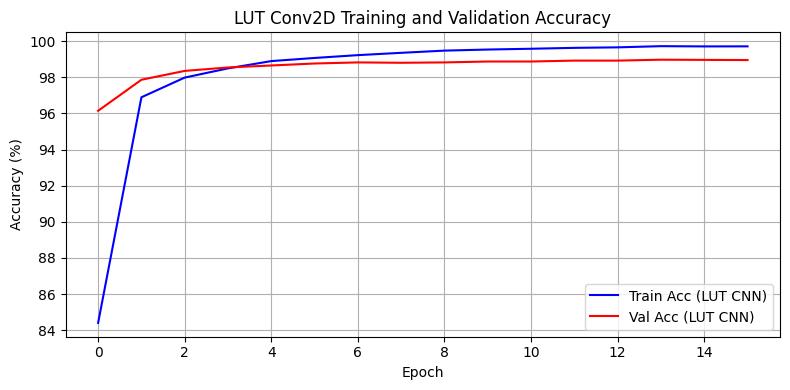

Best validation accuracy: 98.98% at epoch 14


In [20]:
# Plot training curves for LUT Conv2D model
fig, (ax2) = plt.subplots(1, 1, figsize=(8, 4))

# Accuracy plot
ax2.plot(lut_cnn_train_accuracies, label='Train Acc (LUT CNN)', color='blue')
ax2.plot(lut_cnn_test_accuracies, label='Val Acc (LUT CNN)', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('LUT Conv2D Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(
    f"Best validation accuracy: {max(lut_cnn_test_accuracies):.2f}% at epoch "
    f"{lut_cnn_test_accuracies.index(max(lut_cnn_test_accuracies))+1}"
)
